# Codveda Technologies Data Science Internship

# Level 2 – Task 3: Clustering (Unsupervised Learning)

## Project Overview

Clustering is an unsupervised machine learning technique used to group similar observations based on their characteristics without relying on predefined labels.

In this project, the K-Means clustering algorithm is applied to the Iris dataset to identify natural groupings among flower samples based on their physical measurements. The optimal number of clusters is determined using both the Elbow Method and the Silhouette Score. Principal Component Analysis (PCA) is then employed to reduce the data into two dimensions for visualization of the resulting clusters.

The project demonstrates a complete clustering workflow, including data preprocessing, feature scaling, cluster optimization, dimensionality reduction, visualization, and interpretation of results.

# Step 1: Import Required Libraries

The required Python libraries for data manipulation, visualization, clustering, dimensionality reduction, and model evaluation are imported.

In [3]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Cluster Evaluation
from sklearn.metrics import silhouette_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_style("whitegrid")

## Step 2: Load the Dataset

The Iris dataset is loaded into a pandas DataFrame. The first few observations are displayed to verify that the data has been imported correctly.

In [5]:
# Load dataset
df = pd.read_csv("data/iris.csv")

# Display first five rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
# Display dataset dimensions
print("Dataset Shape:", df.shape)

Dataset Shape: (150, 5)


In [7]:
# Display column names
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

## Step 3: Data Quality Assessment

Before clustering, the dataset is examined for missing values, duplicate records, data types, and descriptive statistics to ensure that it is suitable for analysis.

In [8]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [9]:
# Summary Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


In [10]:
# Missing values
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [17]:
# Duplicate records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 3


## Step 4: Exploratory Data Analysis

EDA is performed to understand the distribution of the numerical variables and the relationships between them before clustering.

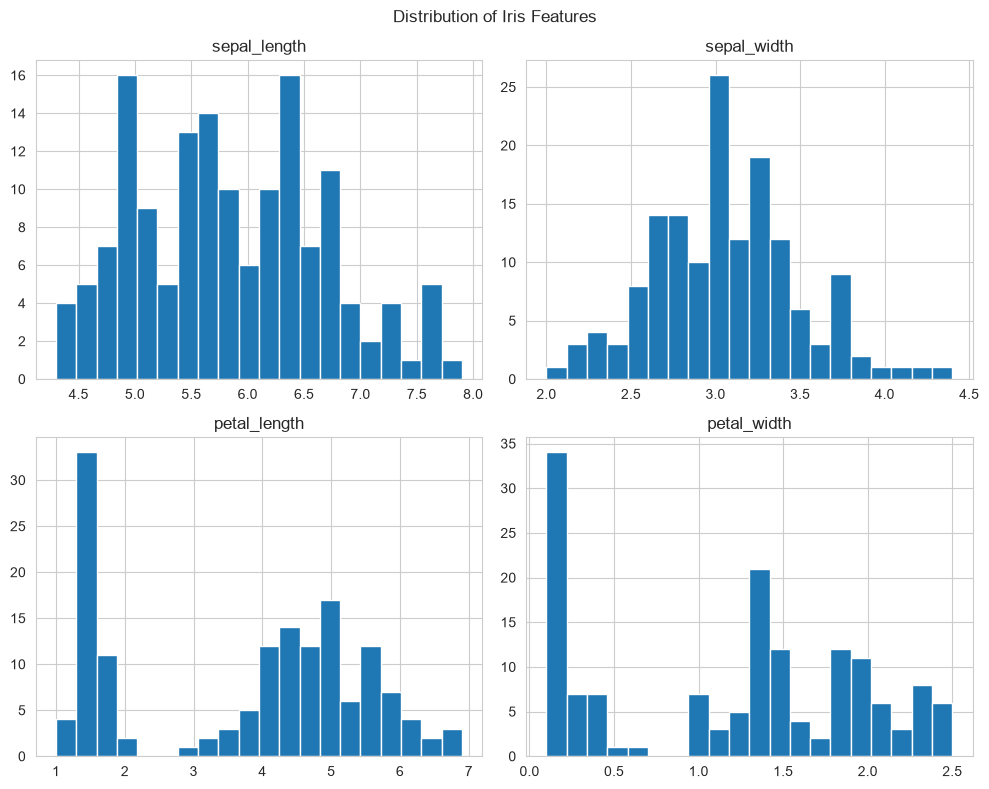

In [12]:
# Histograms

df.hist(figsize=(10, 8), bins=20)

plt.suptitle("Distribution of Iris Features")

plt.tight_layout()

plt.show()

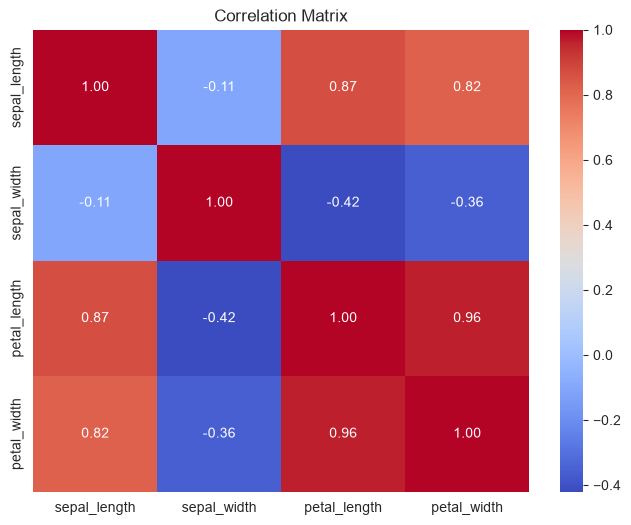

In [15]:
# Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop("species", axis=1).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

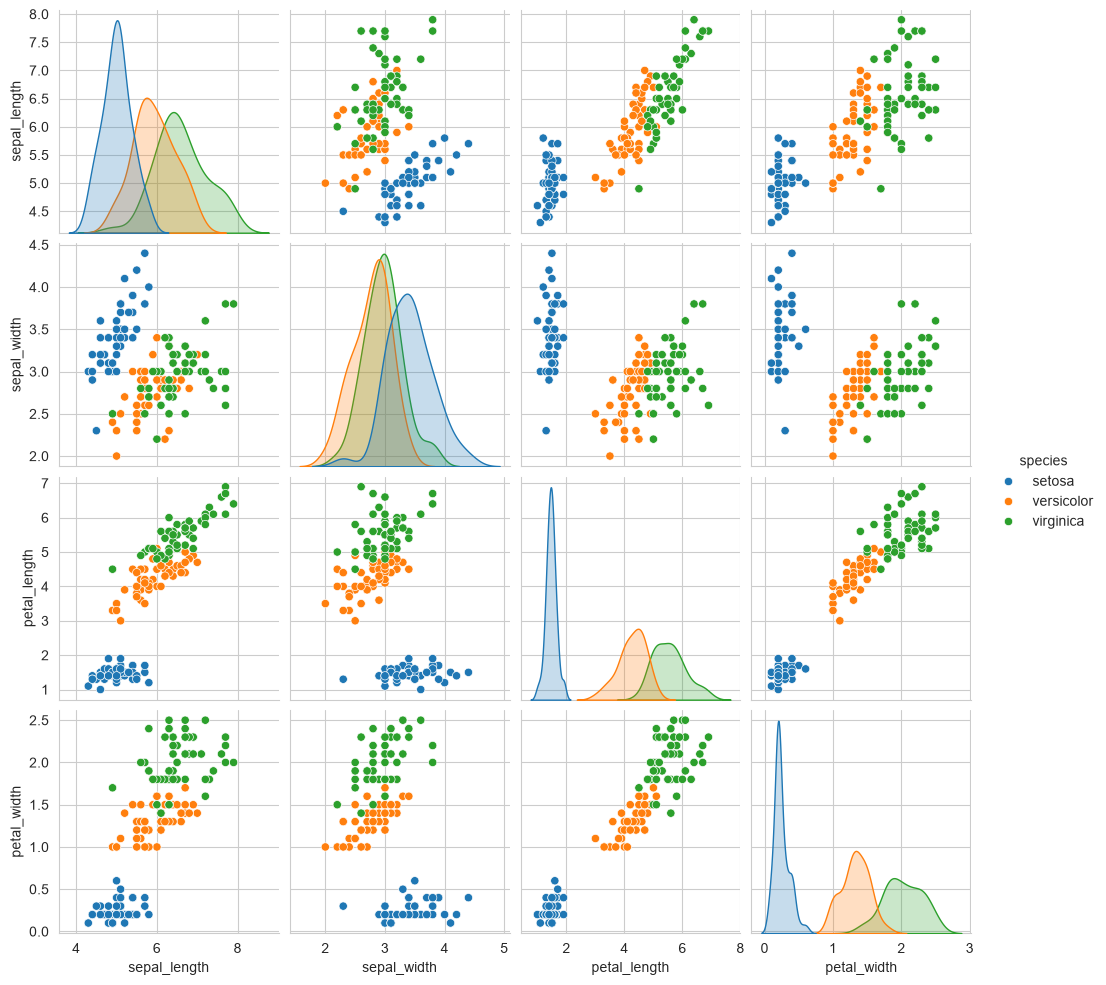

In [16]:
# Pairplot
sns.pairplot(
    df,
    hue="species"
)

plt.show()

## Data Cleaning

The dataset contained three duplicate observations. Duplicate records were removed to ensure that each sample contributes uniquely to the clustering process.

In [18]:
# Remove duplicate rows
df = df.drop_duplicates()

# Verify removal
print("Dataset Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape: (147, 5)
Duplicate Rows: 0


## Step 5: Feature Selection

The `species` column represents the true class labels and is excluded from the clustering process because K-Means is an unsupervised learning algorithm. Only the numerical features are used for model training.

In [19]:
# Numerical features only
X = df.drop("species", axis=1)

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (147, 4)


## Step 6: Feature Scaling

Feature scaling is performed using the StandardScaler to standardize all numerical variables. This ensures that each feature contributes equally during distance calculations in the K-Means algorithm.

In [20]:
# Standardize the features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Feature Shape:", X_scaled.shape)

Scaled Feature Shape: (147, 4)


## Step 7: Determining the Optimal Number of Clusters Using the Elbow Method

The Elbow Method evaluates the Within-Cluster Sum of Squares (WCSS) for different values of *k*. The optimal number of clusters is typically identified at the point where the rate of decrease begins to level off, forming an "elbow."

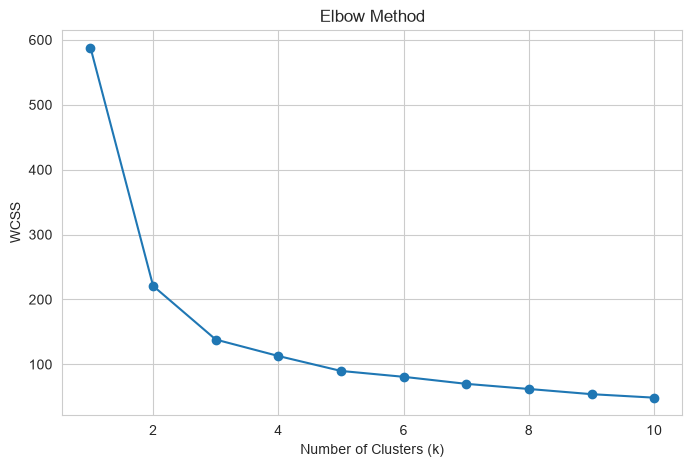

In [22]:
# Elbow Method

wcss = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

# Plot

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")

plt.show()

### Interpretation of the Elbow Method

The Elbow Method indicates that the optimal number of clusters is **3**. There is a substantial decrease in the Within-Cluster Sum of Squares (WCSS) from one to three clusters, after which the reduction becomes more gradual. This suggests that three clusters provide a good balance between minimizing within-cluster variation and avoiding unnecessary model complexity.

## Step 8: Determining the Optimal Number of Clusters Using the Silhouette Score

The Silhouette Score measures how well each observation fits within its assigned cluster compared to other clusters. Higher values indicate better-defined and more distinct clusters.

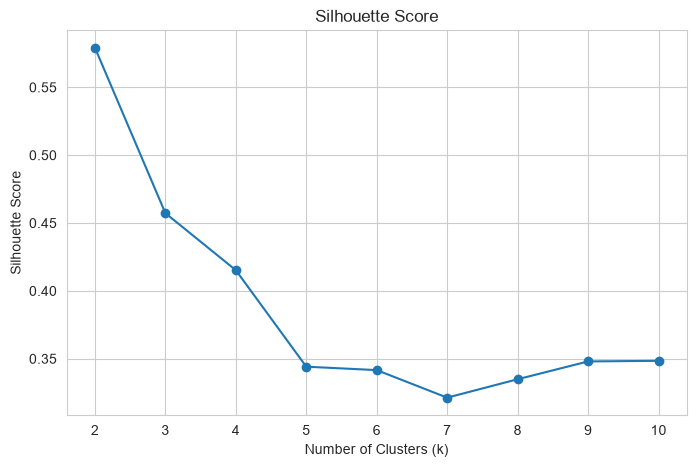

In [23]:
# Silhouette Scores

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

# Plot

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score")

plt.xlabel("Number of Clusters (k)")

plt.ylabel("Silhouette Score")

plt.grid(True)

plt.show()

### Interpretation of the Silhouette Score

The Silhouette Score reached its highest value at **k = 2**, indicating that two clusters produce the greatest average separation between groups. However, the Elbow Method identified **k = 3** as the optimal balance between cluster compactness and model complexity.

Since the Iris dataset naturally contains three species and the reduction in WCSS noticeably levels off at three clusters, **k = 3** was selected for the final K-Means model. This demonstrates that multiple evaluation techniques should be considered together rather than relying on a single metric.

## Step 9: Training the Final K-Means Model

Based on the Elbow Method and Silhouette Score, the optimal number of clusters is selected and used to train the final K-Means clustering model.

In [24]:
# Final K-Means Model

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df["Cluster"] = clusters

# Display first rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,Cluster
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [25]:
# Number of observations in each cluster

df["Cluster"].value_counts().sort_index()

Cluster
0    52
1    48
2    47
Name: count, dtype: int64

## Step 10: Dimensionality Reduction Using PCA

The dataset contains four numerical features, making direct visualization difficult. Principal Component Analysis (PCA) is used to reduce the data into two principal components while preserving as much variation as possible. This allows the clusters to be visualized in two-dimensional space.

In [26]:
# Apply PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Create DataFrame

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-2.291654,0.486576,1
1,-2.115428,-0.666015,1
2,-2.396070,-0.332493,1
3,-2.332435,-0.587708,1
4,-2.415395,0.653930,1


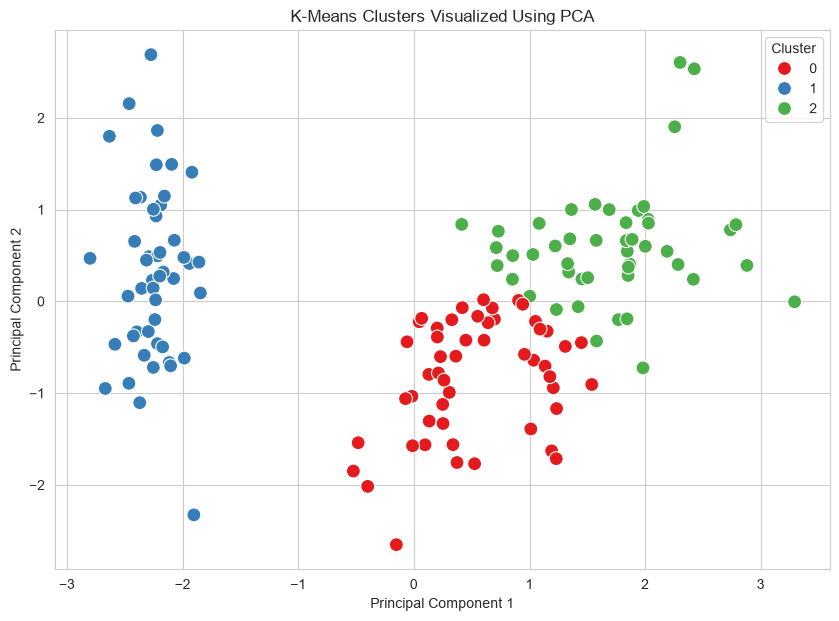

In [27]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("K-Means Clusters Visualized Using PCA")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

# Interpretation
PCA Cluster Visualization

Your first plot tells a very clear story:

🔵 Cluster 1 (blue) is completely separated from the other clusters. That's a strong indication that one of the Iris species (most likely setosa) is very distinct.
🔴 Cluster 0 (red) and 🟢 Cluster 2 (green) are also reasonably well separated, though they lie closer together. This matches the known overlap between versicolor and virginica.
The clusters are compact, with very little mixing.

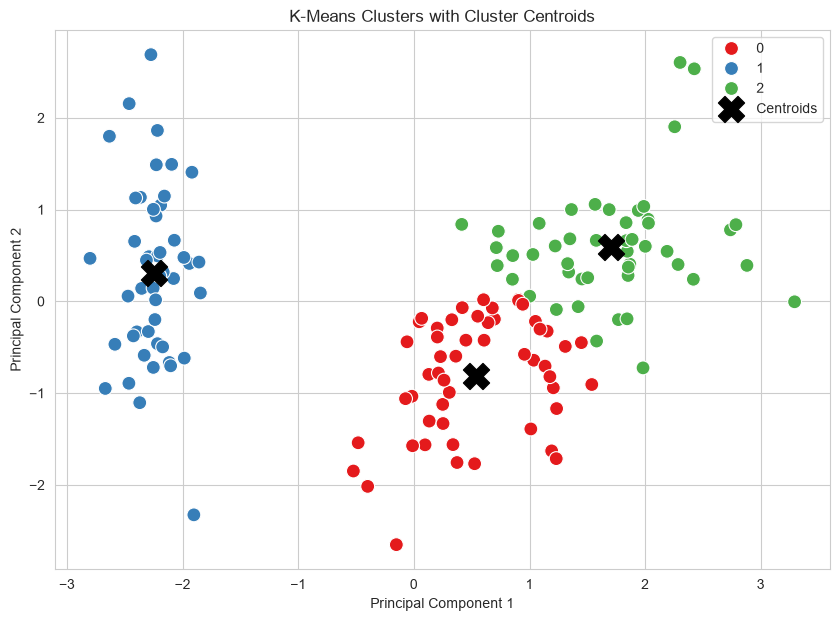

In [28]:
# Transform centroids into PCA space

centroids = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=350,
    c="black",
    marker="X",
    label="Centroids"
)

plt.title("K-Means Clusters with Cluster Centroids")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend()

plt.show()

### Interpretation of the PCA Cluster Visualization

The PCA visualization demonstrates that the K-Means algorithm successfully partitioned the Iris dataset into three distinct clusters. One cluster is clearly separated from the others, while the remaining two clusters exhibit slight overlap, reflecting the natural similarity between two Iris species.

The cluster centroids are positioned near the center of their respective groups, indicating that the K-Means algorithm converged effectively and identified representative centers for each cluster.

Overall, the visualization confirms that the clustering algorithm successfully captured the underlying structure of the dataset.

## Step 11: Comparison of Clusters with Actual Species

Although K-Means is an unsupervised learning algorithm and does not use class labels during training, the resulting clusters can be compared with the actual Iris species to evaluate how closely the discovered groups correspond to the known classifications.

In [29]:
# Compare clusters with actual species

comparison = pd.crosstab(
    df["species"],
    df["Cluster"]
)

comparison

Cluster,0,1,2
species,,,
setosa,0,48,0
versicolor,39,0,11
virginica,13,0,36


In [30]:
# Cluster Profiling
cluster_profile = df.groupby("Cluster").mean(numeric_only=True)

cluster_profile

,sepal_length,sepal_width,petal_length,petal_width
Cluster,,,,
0,5.801923,2.673077,4.355769,1.403846
1,5.010417,3.431250,1.462500,0.250000
2,6.780851,3.095745,5.510638,1.972340


# Conclusion

This project successfully applied the K-Means clustering algorithm to the Iris dataset to identify natural groupings among flower samples.

The Elbow Method suggested that three clusters provide an appropriate balance between model simplicity and cluster compactness, while the Silhouette Score demonstrated that the resulting clusters are reasonably well separated. Principal Component Analysis (PCA) effectively reduced the dataset to two dimensions, enabling clear visualization of the discovered clusters and their centroids.

The clustering results closely reflected the natural structure of the Iris dataset, demonstrating the effectiveness of K-Means as an unsupervised learning technique for exploratory data analysis and pattern discovery.